In [1]:
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import os, sys
# to avoid any possible jupyter crashes due to rpy2 not finding the R install on conda
os.environ['R_HOME'] = sys.exec_prefix+"/lib/R/"

In [2]:
import scanpy as sc
import scFates as scf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

In [3]:
import session_info
session_info.show()

In [4]:
sc.settings.set_figure_params(dpi=80)

# Function

# Variables

In [5]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
celltype = 'SinoatrialNodePacemakerCells'
adata_path = f'{data_object_dir}/b2c_cells_{celltype}_lognorm.h5ad'
celltype_key = 'fine_grain2'

In [6]:
!ls {data_object_dir}

b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
b2c_cells_EndothelialCells_lognorm.h5ad
b2c_cells_EndothelialCells_raw.h5ad
b2c_cells_EpicardialCells_lognorm.h5ad
b2c_cells_EpicardialCells_raw.h5ad
b2c_cells_LymphoidCells_lognorm.h5ad
b2c_cells_LymphoidCells_raw.h5ad
b2c_cells_MesenchymalCells_lognorm.h5ad
b2c_cells_MesenchymalCells_raw.h5ad
b2c_cells_MyeloidCells_lognorm.h5ad
b2c_cells_MyeloidCells_raw.h5ad
b2c_cells_NeuralCells_lognorm.h5ad
b2c_cells_NeuralCells_raw.h5ad
b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_raw.h5ad
scVI


In [7]:
# figdir = '/nfs/team205/heart/fetal_ms_figures/raw_plots_kk/Aug2024'
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

# Read in data

In [8]:
# read in aCM annotated data
adata = sc.read_h5ad(adata_path)
print(adata.X.data[:5])
adata

[2.22104167 2.22104167 2.22104167 2.22104167 2.22104167]


AnnData object with n_obs × n_vars = 3380 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.2', 'leiden_1.5', 'leiden_2.0'
 

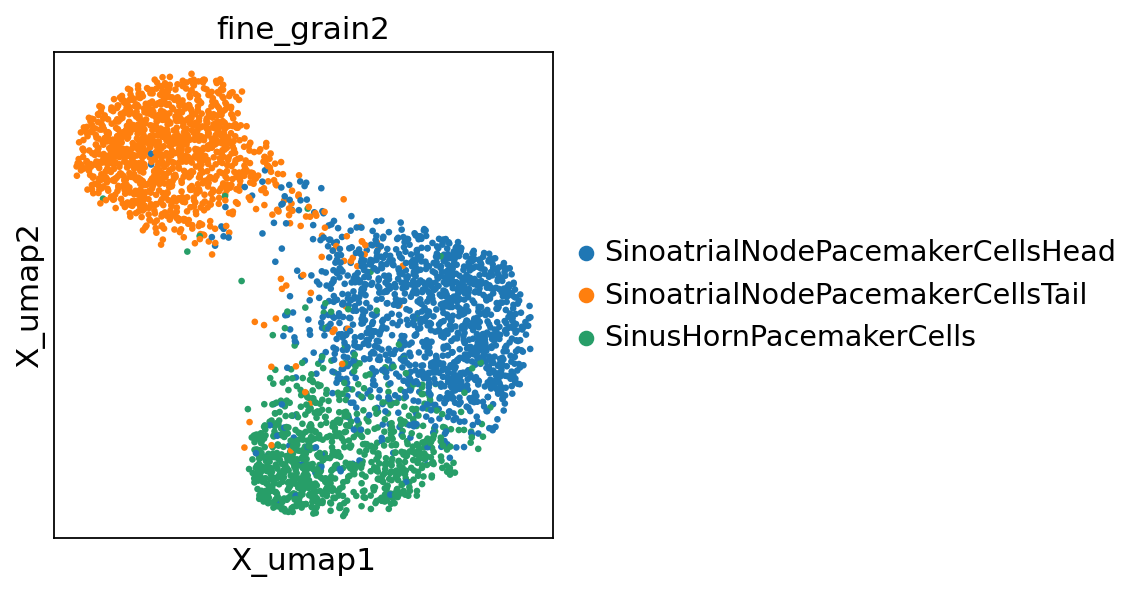

In [9]:
sc.pl.embedding(adata,basis='X_umap',
                color=celltype_key,
                wspace=0.3)

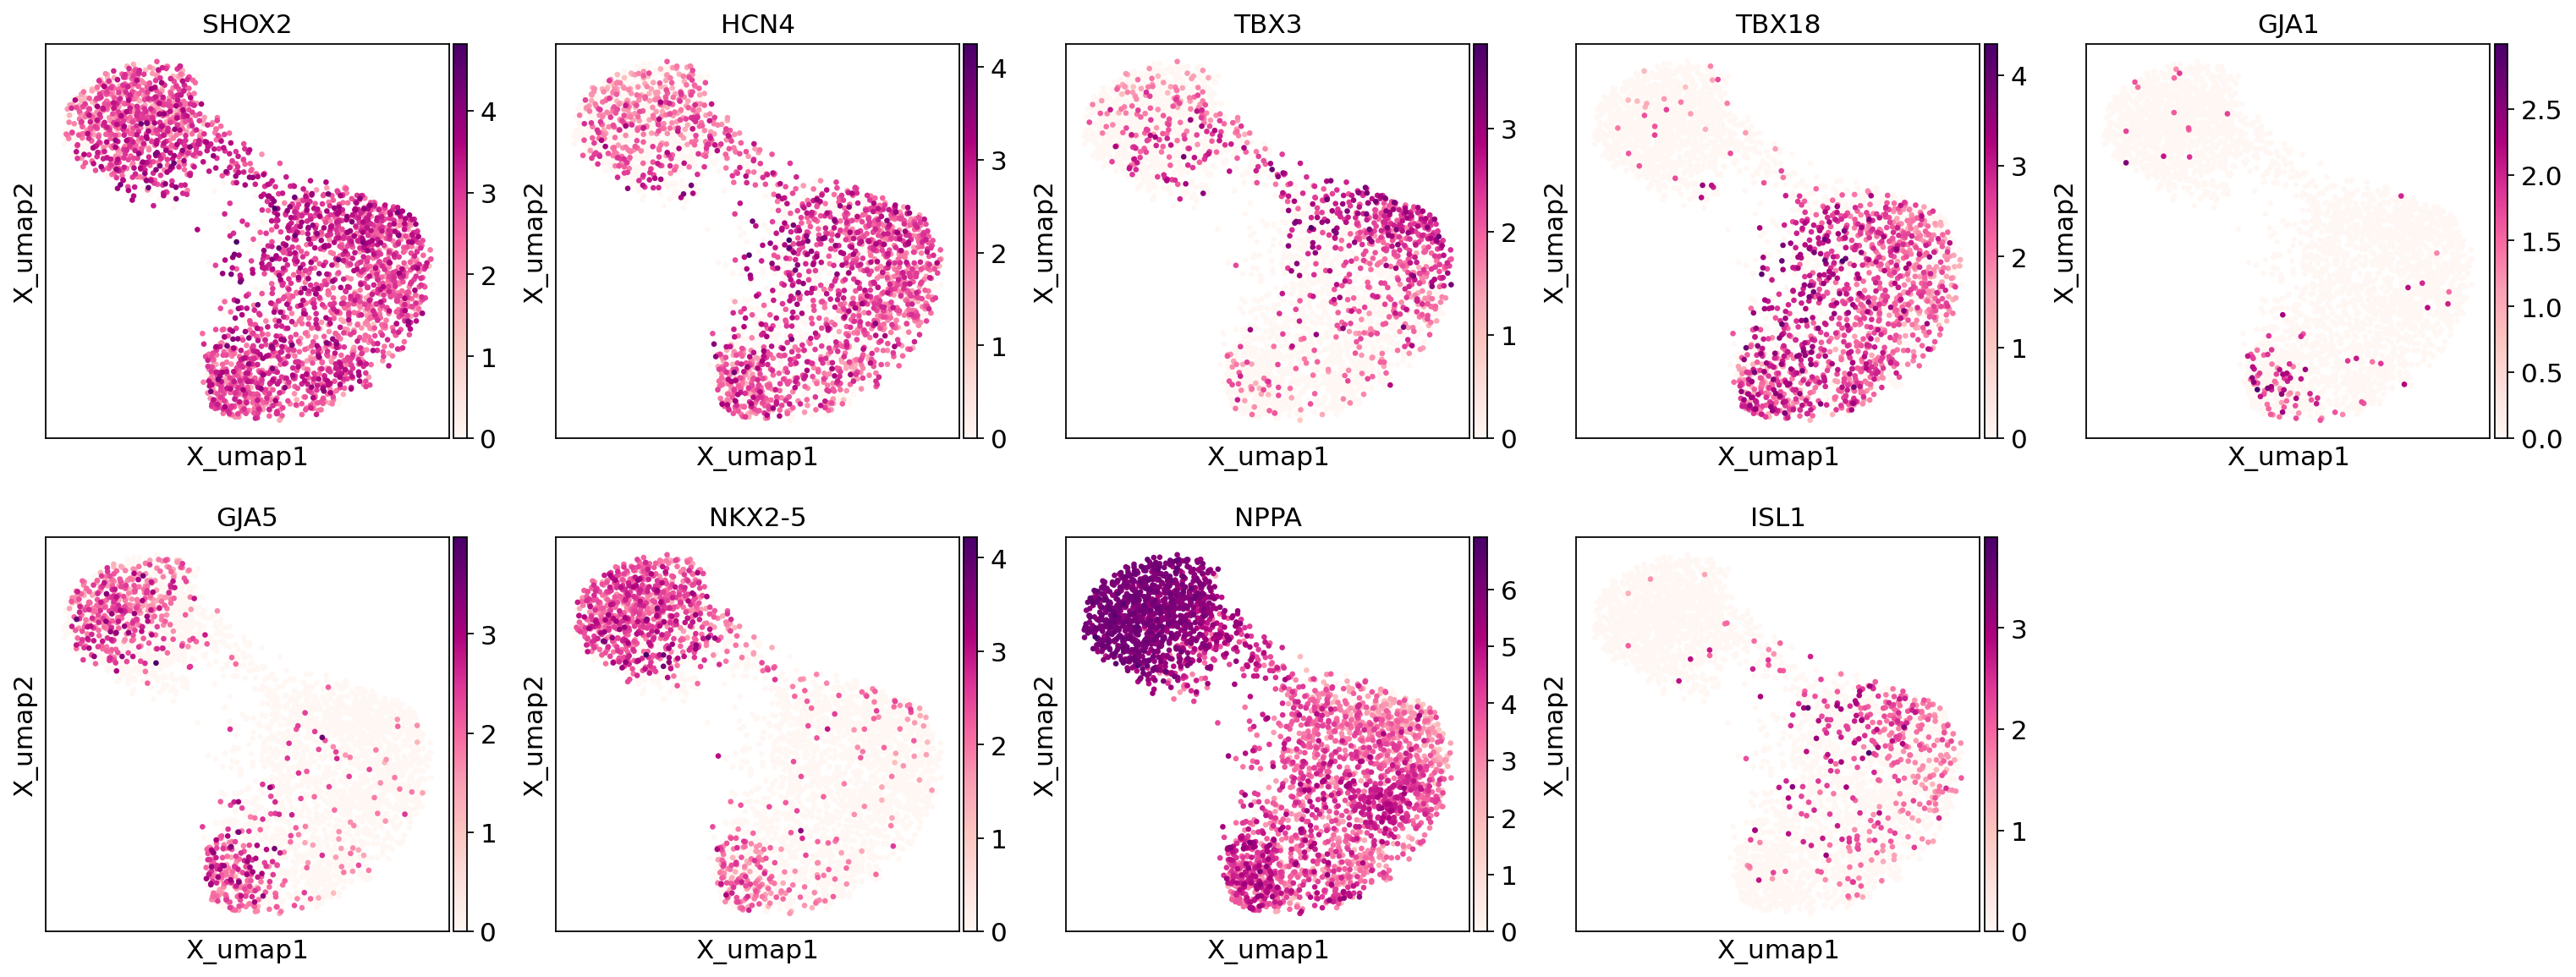

In [10]:
genes = ['SHOX2','HCN4','TBX3','TBX18',
         'GJA1', # CX43
         'GJA5', # CX40
         'NKX2-5',
         'NPPA','ISL1'
        ]
genes = [x for x in genes if x in adata.var_names]
sc.pl.embedding(adata,basis='X_umap',
                color=genes,
               ncols=5, wspace=0.15,cmap='RdPu',vmax='p100')

# Learn curve using ElPiGraph algorithm

In [14]:
scf.tl.curve(adata,Nodes=10,use_rep="X_pca_harmony",ndims_rep=2)

inferring a principal curve --> parameters used 
    10 principal points, mu = 0.1, lambda = 0.01
    finished (0:00:00) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.


# Plotting the tree

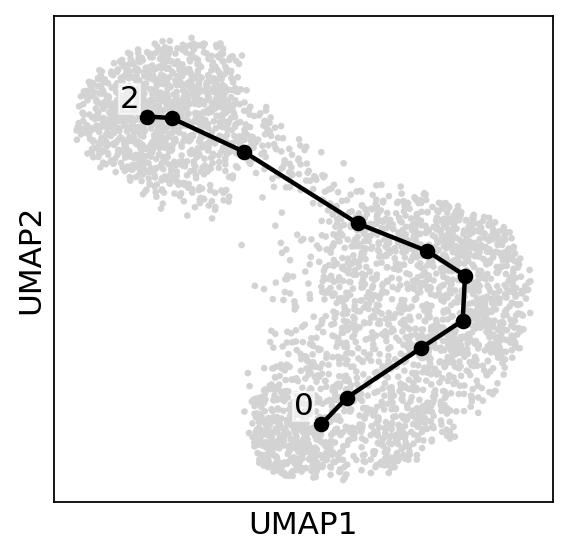

In [15]:
scf.pl.graph(adata,basis='umap')

In [18]:
scf.tl.root(adata,root=0)

node 0 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.


In [24]:
scf.tl.pseudotime(adata,n_jobs=8,n_map=100,seed=42)

projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:19<00:00,  5.24it/s]
    finished (0:00:19) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


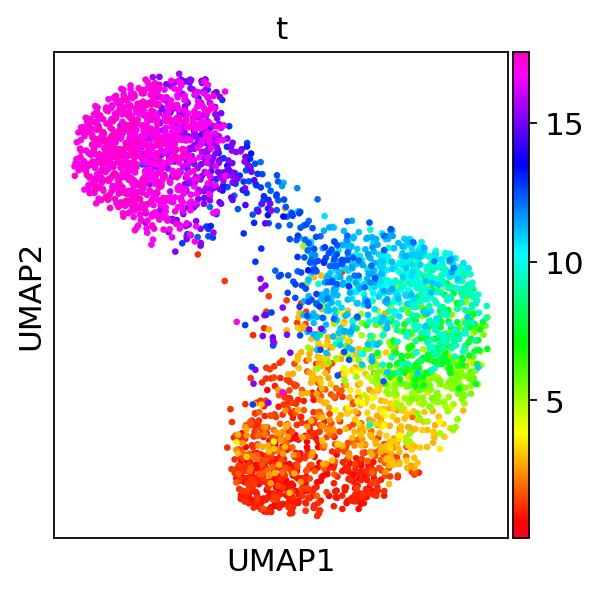

In [30]:
sc.pl.embedding(adata,basis='umap',color="t",cmap='gist_rainbow')

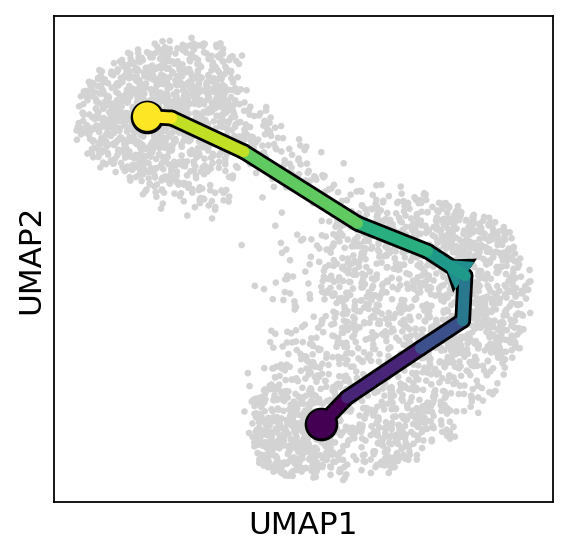

In [27]:
scf.pl.trajectory(adata,basis="umap",arrows=True,arrow_offset=3)

# Save

In [33]:
adata.write(adata_path)
print(adata.X.data[:5])
print(adata_path)

[2.22104167 2.22104167 2.22104167 2.22104167 2.22104167]
/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad


# Annotate the axis

In [6]:
adata = sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 3380 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.2', 'leiden_1.5', 'leiden_2.0', 

### Name the axis and convert

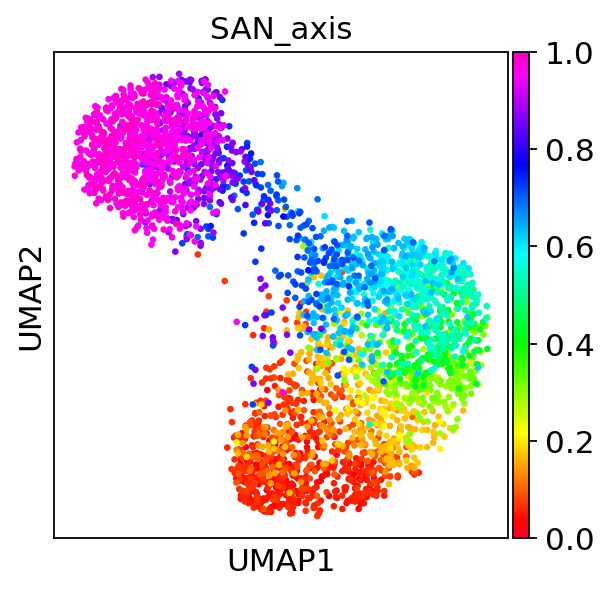

In [10]:
axis_name = 'SAN_axis'
adata.obs[axis_name] = adata.obs['t'].copy()
# convert to 0-1 value
arr = adata.obs[axis_name].copy()
adata.obs[axis_name] = (arr-arr.min())/(arr.max()-arr.min())
# plot
sc.pl.embedding(adata,basis='umap',color=axis_name,cmap='gist_rainbow')

### Binning the axis

In [11]:
# make bin
adata.obs[f'{axis_name}_bin'] = pd.cut(adata.obs[axis_name],bins=10)
set(adata.obs[f'{axis_name}_bin'])

{Interval(-0.001, 0.1, closed='right'),
 Interval(0.1, 0.2, closed='right'),
 Interval(0.2, 0.3, closed='right'),
 Interval(0.3, 0.4, closed='right'),
 Interval(0.4, 0.5, closed='right'),
 Interval(0.5, 0.6, closed='right'),
 Interval(0.6, 0.7, closed='right'),
 Interval(0.7, 0.8, closed='right'),
 Interval(0.8, 0.9, closed='right'),
 Interval(0.9, 1.0, closed='right')}

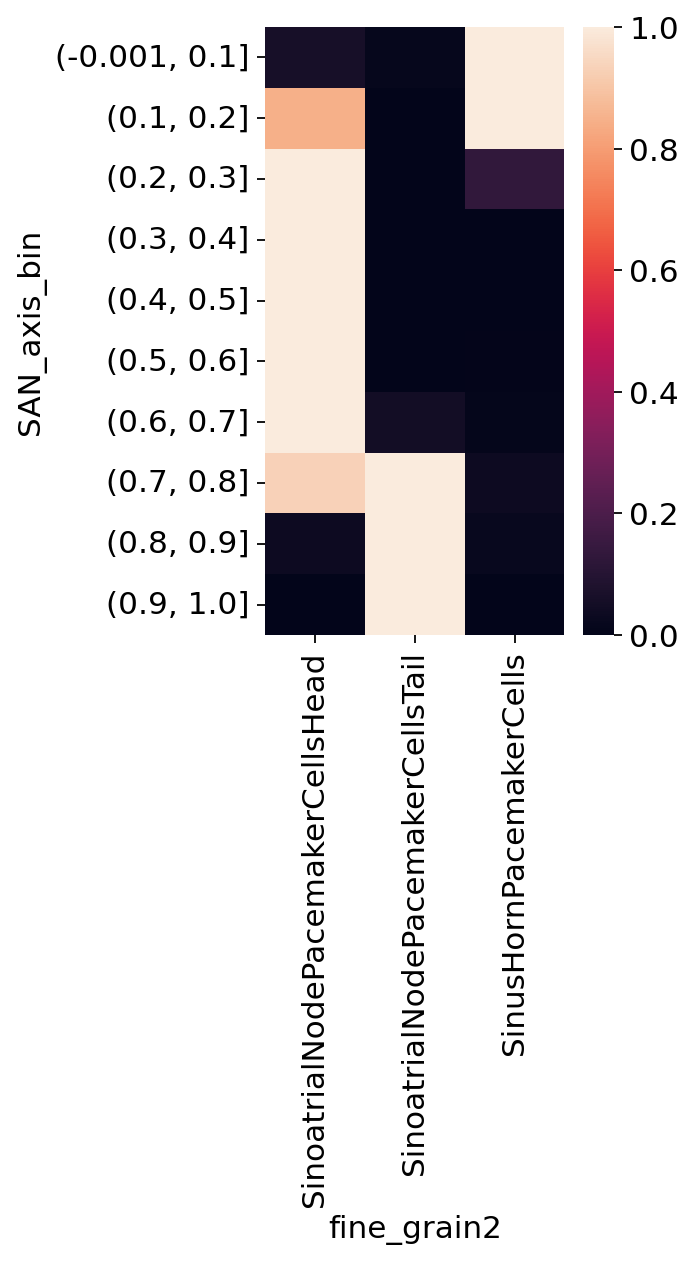

In [18]:
df = adata.obs[[celltype_key]].copy()
df['count']=1
df.reset_index(inplace=True)
df = pd.pivot_table(df, values='count', index=['index'],
                       columns=[celltype_key])
df.fillna(0,inplace=True)
df[f'{axis_name}_bin']=adata.obs.loc[df.index,f'{axis_name}_bin']
df = df.groupby(f'{axis_name}_bin').sum()
max_arr = df.max(axis=1)
for col in df.columns:
    df[col] = df[col]/max_arr
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.figsize'] = 3,5
sns.heatmap(df)

sc.settings.set_figure_params(dpi=80)

In [19]:
# annotate bin
annot_dict = {
    '(-0.001, 0.1]':'SinusHorn_1',
     '(0.1, 0.2]':'SinusHorn_2',
     '(0.2, 0.3]':'SAN_head_1',
     '(0.3, 0.4]':'SAN_head_2',
     '(0.4, 0.5]':'SAN_head_3',
     '(0.5, 0.6]':'SAN_head_4',
     '(0.6, 0.7]':'SAN_head_5',
     '(0.7, 0.8]':'SAN_tail_1',
     '(0.8, 0.9]':'SAN_tail_2',
     '(0.9, 1.0]':'SAN_tail_3',
}
adata.obs[f'{axis_name}_bin_annot'] = adata.obs[f'{axis_name}_bin'].astype('str').copy()
adata.obs.replace({f'{axis_name}_bin_annot':annot_dict}, inplace=True)
adata.obs[f'{axis_name}_bin_annot'] = adata.obs[f'{axis_name}_bin_annot'].astype('category')
adata.obs[f'{axis_name}_bin_annot'] = adata.obs[f'{axis_name}_bin_annot'].cat.reorder_categories(list(annot_dict.values()))
adata.obs[f'{axis_name}_bin_annot'].cat.categories

Index(['SinusHorn_1', 'SinusHorn_2', 'SAN_head_1', 'SAN_head_2', 'SAN_head_3',
       'SAN_head_4', 'SAN_head_5', 'SAN_tail_1', 'SAN_tail_2', 'SAN_tail_3'],
      dtype='object')

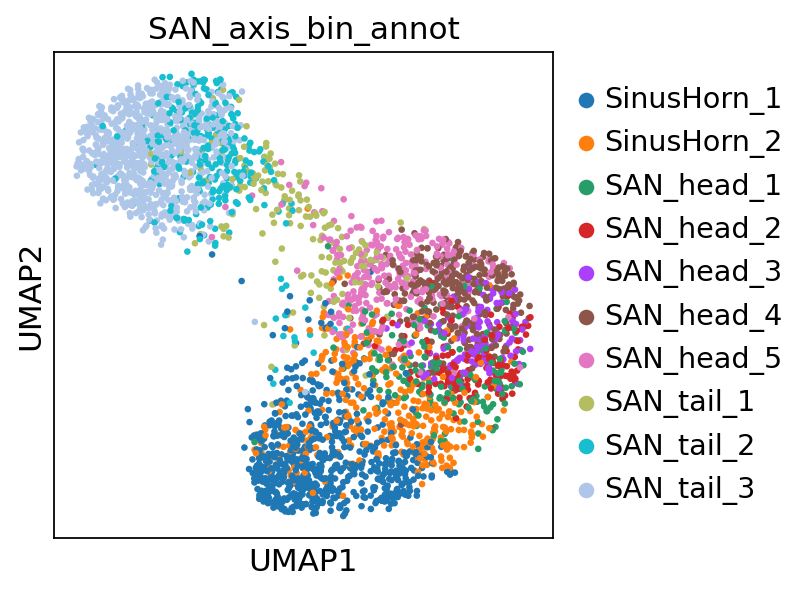

In [20]:
# plot
sc.pl.embedding(adata,basis='umap',color=f'{axis_name}_bin_annot')

### Save

In [22]:
adata.obs.drop([f'{axis_name}_bin'],axis=1,inplace=True) # gets error while saving
adata.write(adata_path)
print(adata.X.data[:5])
print(adata_path)

[2.22104167 2.22104167 2.22104167 2.22104167 2.22104167]
/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad


# Plot on section

In [23]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

In [24]:
# read in original adata
cdata = sc.read_h5ad(f'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad')
cdata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2'
    var: 'gene_ids', 'feature_

In [25]:
cdata.obs['fine_grain'] = 'nan'
cdata.obs.loc[adata.obs_names,axis_name] = adata.obs[axis_name].copy()

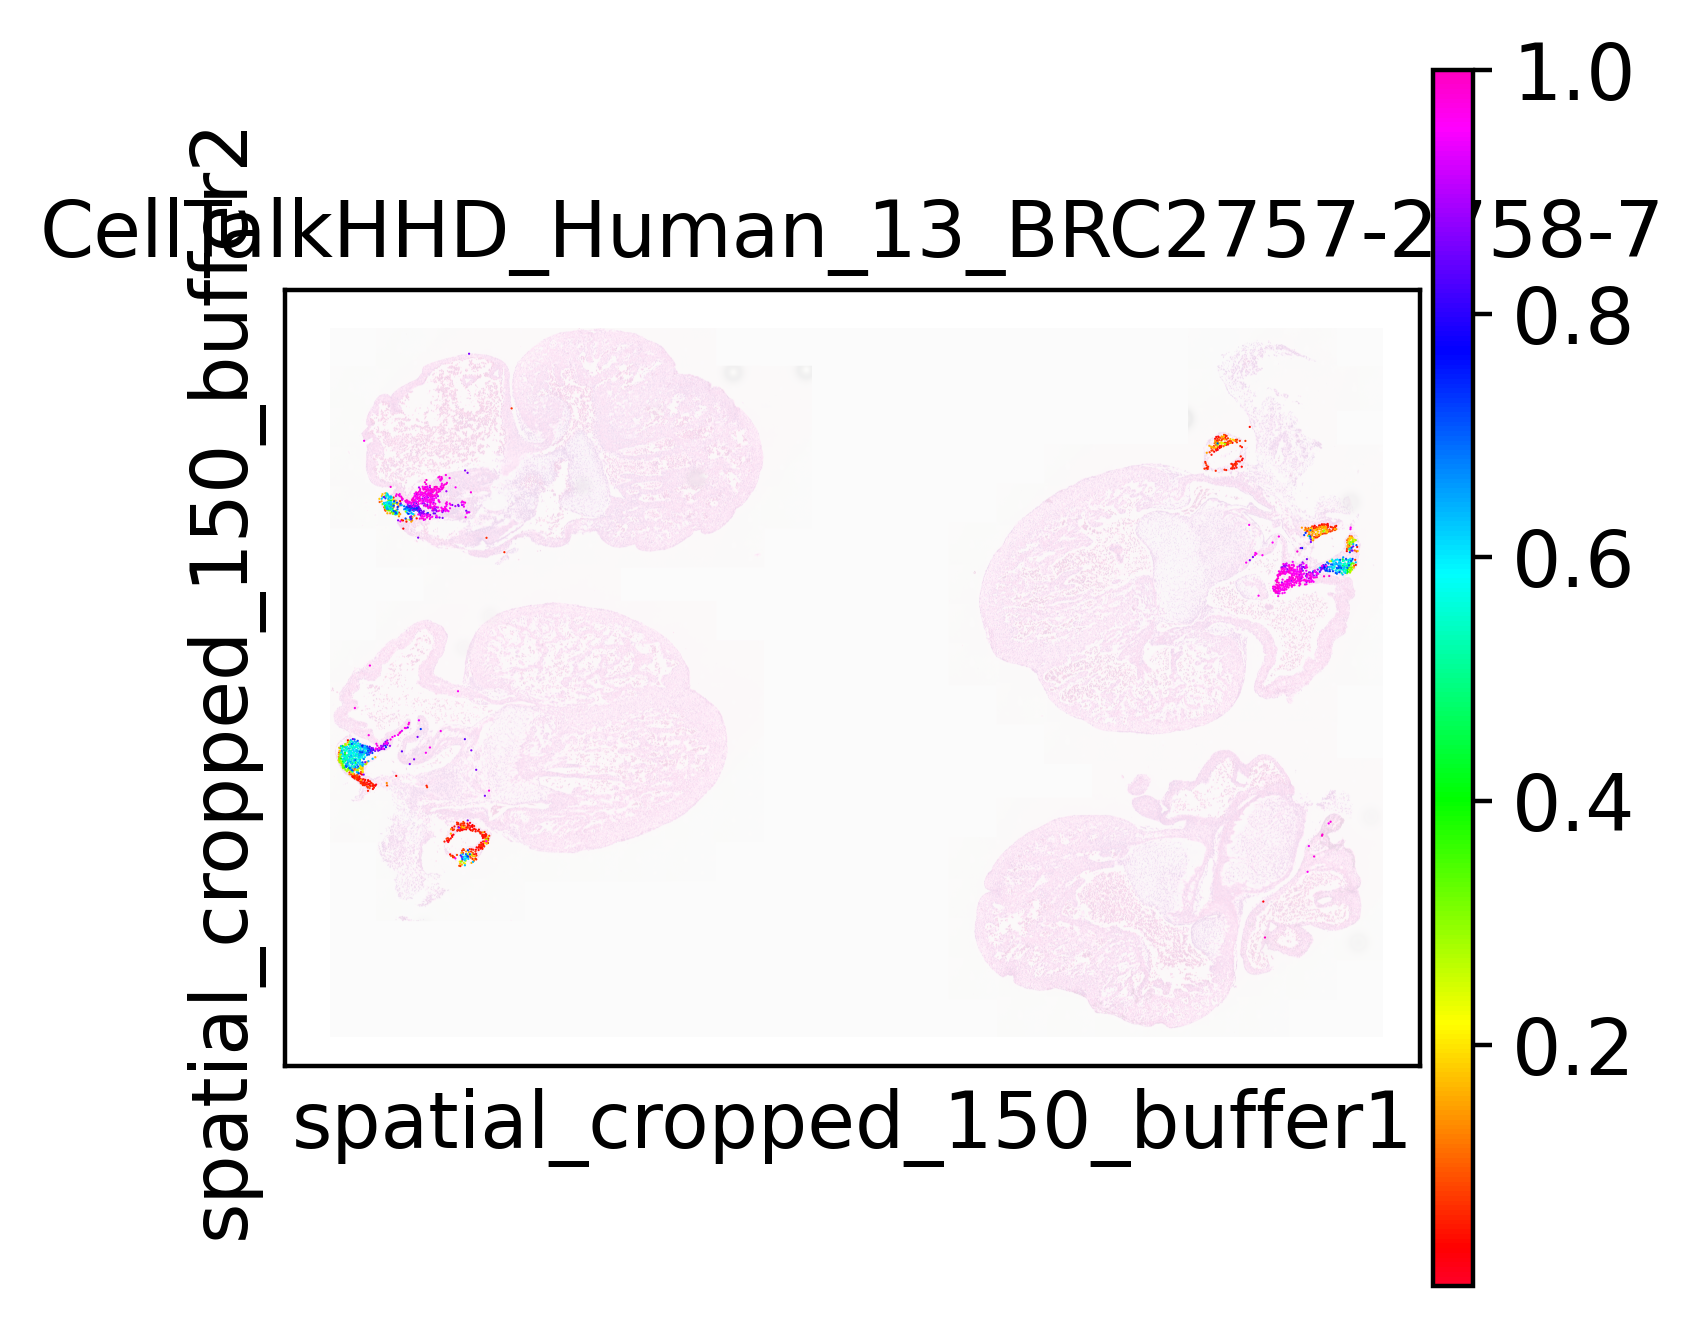

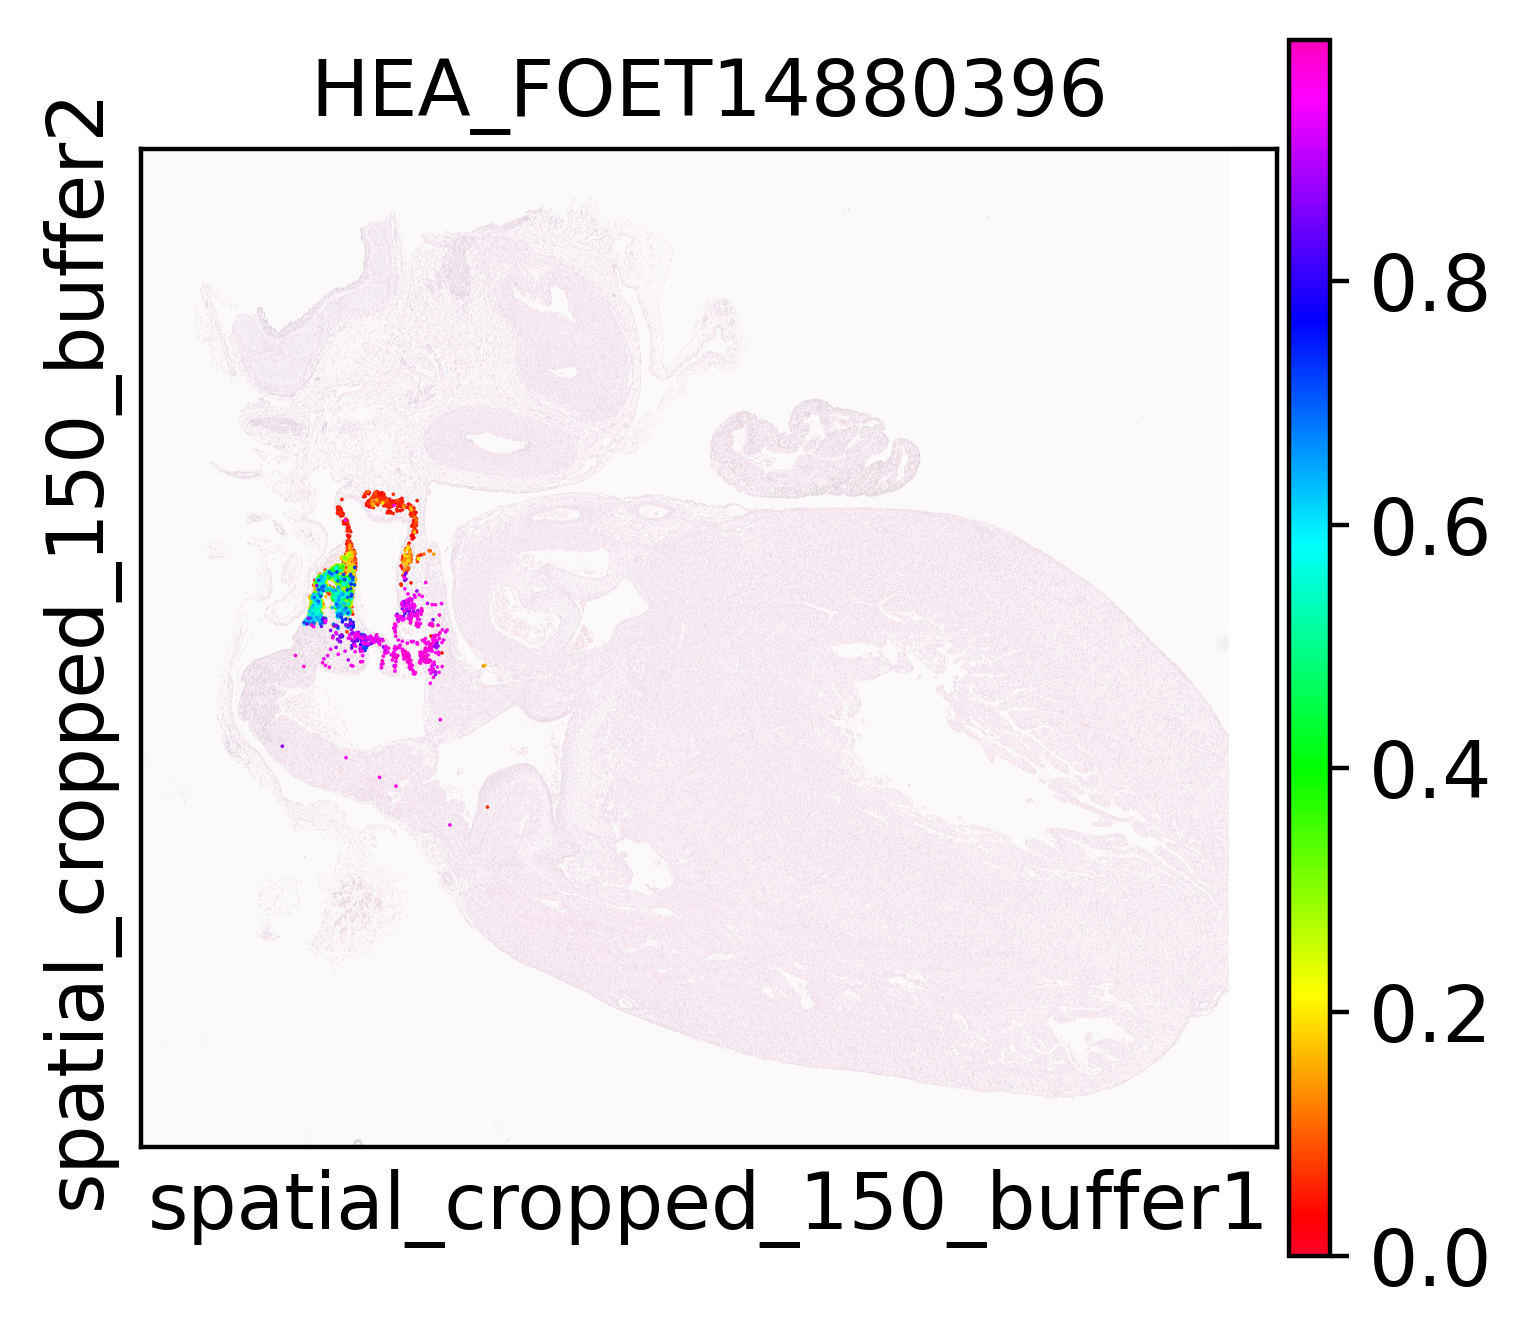

In [26]:
sc.settings.set_figure_params(dpi=200)

# plotting for inspection
sample_list = list(set(cdata.obs['library']))
sample_list.sort()

for sample_id in sample_list:
    # subsetting
    slide = select_slide(cdata, sample_id, s_col='library')
    sc.pl.spatial(slide, color=[axis_name], cmap='gist_rainbow',
                  img_key="0.3_mpp_150_buffer", basis="spatial_cropped_150_buffer",
                  alpha_img=0.2,
                  title=sample_id,spot_size=100)